Для функции, заданной таблично, вычислить значение интеграла с использованием
формулы трапеций. Оценить погрешность полученного значения интеграла с помощью
правила Рунге.


| $x$   | $f(x)$ |
|:-----:|:------:|
| -1    | -0.333 |
| -0.75 | 0      |
| -0.5  | -0.125 |
| -0.25 | -0.056 |
| 0     | 0      |
| 0.25  | 0.046  |
| 0.5   | 0.083  |
| 0.75  | 0.115  |
| 1     | 0.143  |

Оценка точности по правилу Рунге, для шага $h/2$:
$$\Delta_{h/2} = \frac{|I_{h/2} - I_{h} |}{2^p - 1} $$
$p$ - порядок погрешности относитльно $h$  (В случае трапеции $p = 2$)

In [9]:
import matplotlib.pyplot as plt
import numpy as np

In [16]:
X = [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]
Y = [-0.333, 0, -0.125, -0.056, 0, 0.046, 0.083, 0.115, 0.143]

In [19]:
# Интерполяция первой формулой Ньютона
def k_coeff(ind, k):
    res = 1
    for j in range(ind):
        res *= k - j
        
    return res

def fact(a):
    res = 1
    for i in range(1, a + 1):
        res *= i
        
    return res

def x_coeff(x, ind):
    global X
    res = 1
    
    for i in range(ind):
        res *= x - X[i]
    return res

def C(m, n):
    return fact(n) / (fact(n - m) * fact(m))

def FiniteDifference(k):    
    res = 0
    for j in range(0, k + 1):
        res += np.pow(-1, k - j) * C(j, k) * Y[j]
    return res

def InterpolNewtonFK(x):
    result = Y[0]
    H = 0.25
    
    for i in range(1, len(X)):
        result += FiniteDifference(i) * x_coeff(x, i) / np.pow(H, i) / fact(i)
    return result

In [25]:
x_n_f = np.linspace(X[0], X[-1], 1000)
y_n_f = [InterpolNewtonFK(el) for el in x_n_f]

Интерполяция с помощью первой формулы Ньютона(вперёд)
Данные:
[-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]
[-0.333, 0, -0.125, -0.056, 0, 0.046, 0.083, 0.115, 0.143]


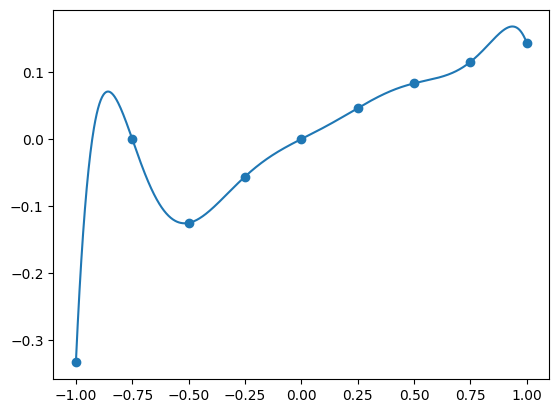

In [26]:
print("Интерполяция с помощью первой формулы Ньютона(вперёд)\nДанные:")
print(X, Y, sep='\n')
plt.plot(x_n_f, y_n_f)
plt.scatter(X, Y)

In [39]:
2 // 0.05

39.0

In [34]:
def CalcIntegralTrapezoid(x_start, x_end, H):
    res = (InterpolNewtonFK(x_start) + InterpolNewtonFK(x_end)) / 2
    N = int((x_end - x_start) // H) + 1
    
    for i in range(0, N - 1):
        res += InterpolNewtonFK(x_start + i * H)
    
    res *= H
    
    return res

In [35]:
CalcIntegralTrapezoid(-1, 1, 0.25)

np.float64(-0.0912500000000028)

In [36]:
def RungeRule(h):
    p = 2
    
    I_h = CalcIntegralTrapezoid(-1, 1, h)
    I_h2 = CalcIntegralTrapezoid(-1, 1, 2 * h)
    
    return np.abs(I_h2 - I_h) / (2**p - 1)

In [53]:
H_0 = 0.001
I = CalcIntegralTrapezoid(-1, 1, H_0)

print(f'Значение интеграла для h = {H_0}\nI = {I}')

RR = RungeRule(H_0)

print(f'Оценка по Рунге для h = {H_0}\ndelta = {RR}')

Значение интеграла для h = 0.001
I = 0.029379628357381768
Оценка по Рунге для h = 0.001
delta = 0.00016023803034813724
